<a href="https://colab.research.google.com/github/ayatayoub20/intermediate-machine-learning-projects/blob/main/Dimensionality_Reduction/PCA_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None,
        cmap='gist_gray',
        colorbar=colorbar,
        ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize,
        cmap=cmap,
        colorbar=colorbar,
        ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred,
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_train,
        colorbar=colorbar,
        label='Training Data'
    )

    print()

    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred,
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_test,
        colorbar=colorbar,
        label='Test Data'
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}


## Load the Dataset

In [ ]:
# Get Data
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week09/Data/NHANES_Diet_Diabetes_Risk.xls.csv')
df.head()

,SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,...,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V,Diabetes_Risk
0,73557,16888.32786,12930.89065,1,49.0,2.0,2.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,73558,17932.14387,12684.14887,1,59.0,2.0,2.0,4.0,1.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2
2,73559,59641.81293,39394.23671,1,49.0,2.0,2.0,18.0,6.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,73561,59052.35703,39004.89299,1,63.0,2.0,2.0,18.0,1.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,0
4,73562,49890.82866,0.00000,1,49.0,2.0,1.0,11.0,3.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,0


In [ ]:
df.dtypes.value_counts()

,count
float64,166
int64,3


We can see that all of the data is numeric.

In [ ]:
df.isna().sum().sum()

np.int64(432597)

In [ ]:
df = df.set_index('SEQN')
df.head()

,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,...,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V,Diabetes_Risk
SEQN,,,,,,,,,,,,,,,,,,,,,
73557,16888.32786,12930.89065,1,49.0,2.0,2.0,6.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
73558,17932.14387,12684.14887,1,59.0,2.0,2.0,4.0,1.0,1.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2
73559,59641.81293,39394.23671,1,49.0,2.0,2.0,18.0,6.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
73561,59052.35703,39004.89299,1,63.0,2.0,2.0,18.0,1.0,1.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,0
73562,49890.82866,0.00000,1,49.0,2.0,1.0,11.0,3.0,1.0,1.0,...,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,0


In [ ]:
target = 'Diabetes_Risk'

X = df.drop(columns=target)
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

# Data Preprocessing

In [ ]:
imputer = SimpleImputer(strategy='median')

scaler = StandardScaler()

In [ ]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['DRQSDT5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['DRQSDT5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
X_train_tf = scaler.fit_transform(X_train_imputed)
X_test_tf = scaler.transform(X_test_imputed)

In [ ]:
# Check for class balance of target
y_train.value_counts(1)

,proportion
Diabetes_Risk,
0,0.819952
2,0.092332
1,0.087716


# Handle Class Imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE,SMOTENC
smote = SMOTE()
X_train_sm, y_train_sm = smote.fit_resample(X_train_tf, y_train)
y_train_sm.value_counts()

,count
Diabetes_Risk,
2,4085
1,4085
0,4085


#MODEL 1 — WITHOUT PCA

In [ ]:

# Import datetime library
import datetime as dt

# Record the start time
start = dt.datetime.now()

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train_sm, y_train_sm)

KNeighborsClassifier()

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.56      0.64      4085
           1       0.80      0.90      0.84      4085
           2       0.81      0.91      0.86      4085

    accuracy                           0.79     12255
   macro avg       0.78      0.79      0.78     12255
weighted avg       0.78      0.79      0.78     12255



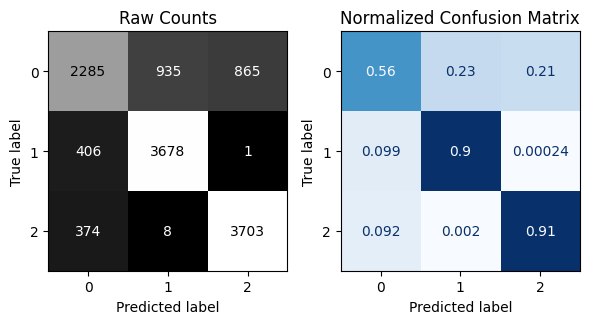


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.43      0.57      1367
           1       0.09      0.30      0.14       150
           2       0.10      0.32      0.15       144

    accuracy                           0.41      1661
   macro avg       0.34      0.35      0.29      1661
weighted avg       0.70      0.41      0.49      1661



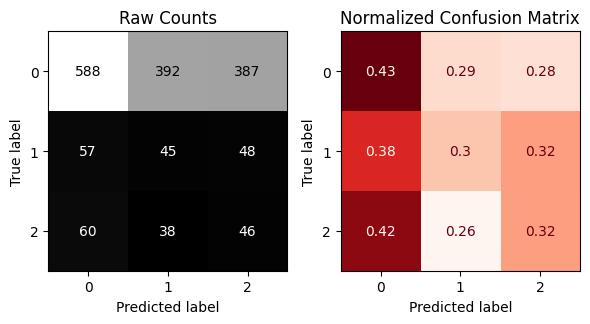

Training time was: 0:00:44.732923


In [ ]:
# Record the end time and calc duration
end = dt.datetime.now()
dur_baseline = end-start

evaluate_classification(knn, X_train_sm,y_train_sm, X_test_tf, y_test)
print(f'Training time was: {dur_baseline}')

# Apply PCA

In [ ]:
pca = PCA(n_components=.95)

In [ ]:
X_train_pca = pca.fit_transform(X_train_sm)
X_test_pca = pca.transform(X_test_tf)
X_train_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca86,pca87,pca88,pca89,pca90,pca91,pca92,pca93,pca94,pca95
0,-3.089742,-1.421034,-0.558189,-1.806377,-0.174324,0.150700,0.043113,-0.276191,0.134198,0.487779,...,-0.089335,-0.172217,0.511835,0.088989,-0.095745,-0.245515,-0.419739,0.322963,-0.039007,0.020560
1,-3.846093,-2.622637,-0.899878,-1.095917,1.590895,-2.698686,-1.893345,-1.857463,-1.190862,-0.504483,...,0.534239,-0.231431,0.124987,0.615890,-0.282530,0.207823,0.354780,-0.545556,0.182628,-0.114321
2,-3.082377,1.097171,-2.045423,-0.129156,1.596318,0.217117,0.628189,-0.392352,-0.255233,1.077525,...,-0.434524,0.171808,0.190414,-0.009909,-0.201497,-0.145245,-0.205867,-0.174964,-0.040238,0.487539
3,0.417098,-0.569623,1.474640,-0.503204,-2.097767,0.758177,-0.186587,-0.330335,0.352981,0.229006,...,-0.281291,-0.236732,0.221276,0.077665,0.287465,0.430811,-0.141990,-0.332477,0.041403,-0.734856
4,9.057229,3.142983,-1.101260,0.613132,1.929647,1.176928,0.215581,0.194906,0.693394,-0.687599,...,0.294399,0.060721,-0.913068,-0.699490,-0.747815,-1.420953,-0.066062,-0.194297,0.677786,-1.548682


In [ ]:
pca.n_components_

np.int64(96)

#MODEL 2 — WITH PCA

In [ ]:
# Record the start time
start = dt.datetime.now()

In [ ]:
knn_pca = KNeighborsClassifier()

In [ ]:
knn_pca.fit(X_train_pca, y_train_sm)

KNeighborsClassifier()

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.58      0.66      4085
           1       0.81      0.90      0.85      4085
           2       0.81      0.91      0.86      4085

    accuracy                           0.80     12255
   macro avg       0.79      0.80      0.79     12255
weighted avg       0.79      0.80      0.79     12255



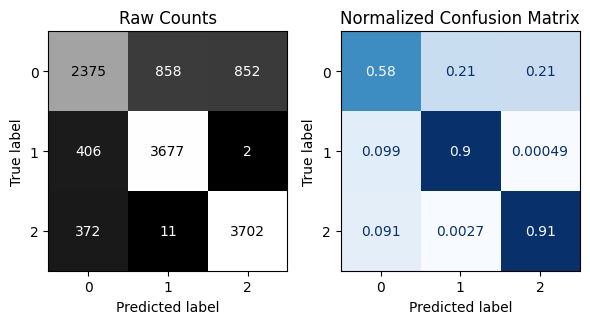


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.43      0.57      1367
           1       0.10      0.31      0.15       150
           2       0.09      0.30      0.14       144

    accuracy                           0.41      1661
   macro avg       0.34      0.35      0.29      1661
weighted avg       0.70      0.41      0.49      1661



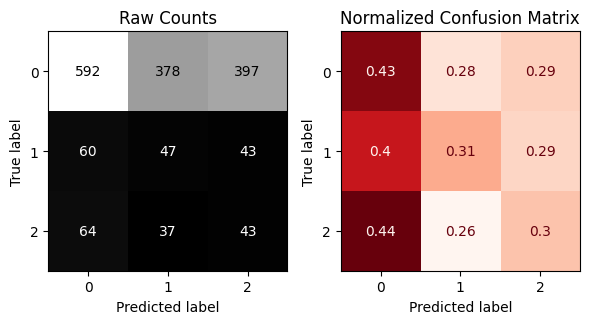

Training time was: 0:00:39.847934


In [ ]:
# Record the end time and calc duration
end = dt.datetime.now()
dur_pca = end-start

evaluate_classification(knn_pca, X_train_pca,y_train_sm, X_test_pca, y_test)
print(f'Training time was: {dur_pca}')

In [ ]:
# Compare speeds before and after PCA
compare_speed = dur_baseline/dur_pca
print(f"Using PCs was {compare_speed:.2f} times faster!")

Using PCs was 1.12 times faster!


# Model Comparison

## Q1. How many features were used in the first model, and how many PCs were used in the PCA model?

The first KNN model used all of the original features in the dataset.

The PCA model reduced the dimensionality and used only the principal components required to preserve 95% of the variance in the data.

---

## Q2. Which model performed the best on the test set?

Both models achieved similar overall performance on the test set. However, the non-PCA model performed slightly better overall based on the classification metrics.

I also experimented with SMOTE to address the class imbalance in the dataset. While SMOTE improved recall for the minority classes, it significantly reduced the overall accuracy. This suggests that KNN was sensitive to the synthetic samples generated by SMOTE.

---

## Q3. Which model was the fastest at making predictions?

The PCA model was the fastest.

Using PCA reduced the prediction time and made the model approximately 1.12 times faster than the model trained on the original feature set.
